# Phase 2 — Notebook 03: Model Tuning & Architecture Search

**From NB02:** Best clean model = 0.8489 (93 feat, no ELO/DC). Gap to Phase 1: 0.05.
EA features = 35.7% of model importance. Most EA features are redundant (one big cluster).

**This notebook:**
1. Add just `elo_diff` — how much of the 0.05 gap does it close?
2. Hyperparameter tuning on best feature set
3. Try multiple model architectures
4. Final model selection

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import log_loss, accuracy_score, f1_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_DIR = Path('../../data')
PROCESSED_DIR = DATA_DIR / 'processed'

train_df = pd.read_csv(PROCESSED_DIR / 'train_dc.csv')
test_df = pd.read_csv(PROCESSED_DIR / 'test_dc.csv')
team_features = pd.read_csv(PROCESSED_DIR / 'team_features_by_year.csv')

train_df['date'] = pd.to_datetime(train_df['date'])
test_df['date'] = pd.to_datetime(test_df['date'])
train_df['year'] = train_df['date'].dt.year
test_df['year'] = test_df['date'].dt.year

print(f'Train: {len(train_df):,d} | Test: {len(test_df):,d}')

Train: 35,304 | Test: 3,313


In [2]:
# ── Join squad features & engineer all features ──
SQUAD_FEATURES = [
    'squad_avg_overall', 'squad_median_overall', 'squad_std_overall',
    'squad_top3_avg', 'squad_bottom5_avg',
    'gk_avg', 'def_avg', 'mid_avg', 'fwd_avg',
    'strongest_unit', 'weakest_unit',
    'squad_total_value', 'squad_avg_value',
    'squad_avg_age', 'squad_avg_potential_gap', 'squad_avg_caps',
    'team_pace', 'team_shooting', 'team_passing',
    'team_dribbling', 'team_defending', 'team_physic',
]

def join_and_engineer(df):
    df = df.copy()
    avail = sorted(team_features['year'].unique())
    def get_yr(y):
        c = [x for x in avail if x <= y]
        return max(c) if c else None
    df['fifa_year'] = df['year'].apply(get_yr)
    
    htf = team_features.rename(columns={f: f'home_{f}' for f in SQUAD_FEATURES})
    htf = htf.rename(columns={'team': 'home_team', 'year': 'fifa_year'})
    atf = team_features.rename(columns={f: f'away_{f}' for f in SQUAD_FEATURES})
    atf = atf.rename(columns={'team': 'away_team', 'year': 'fifa_year'})
    
    home_cols = ['home_team', 'fifa_year'] + [f'home_{f}' for f in SQUAD_FEATURES]
    away_cols = ['away_team', 'fifa_year'] + [f'away_{f}' for f in SQUAD_FEATURES]
    
    df = df.merge(htf[home_cols], on=['home_team', 'fifa_year'], how='left')
    df = df.merge(atf[away_cols], on=['away_team', 'fifa_year'], how='left')
    
    # All 22 diffs
    for f in SQUAD_FEATURES:
        df[f'{f}_diff'] = df[f'home_{f}'] - df[f'away_{f}']
    
    # Engineered features from NB02
    df['overall_ratio'] = df['home_squad_avg_overall'] / df['away_squad_avg_overall'].clip(lower=1)
    df['top3_ratio'] = df['home_squad_top3_avg'] / df['away_squad_top3_avg'].clip(lower=1)
    df['value_ratio_log'] = np.log1p(df['home_squad_total_value']) - np.log1p(df['away_squad_total_value'])
    df['value_ratio'] = (df['home_squad_total_value'] + 1) / (df['away_squad_total_value'] + 1)
    
    df['home_squad_balance'] = df['home_strongest_unit'] - df['home_weakest_unit']
    df['away_squad_balance'] = df['away_strongest_unit'] - df['away_weakest_unit']
    df['squad_balance_diff'] = df['home_squad_balance'] - df['away_squad_balance']
    
    df['home_star_gap'] = df['home_squad_top3_avg'] - df['home_squad_avg_overall']
    df['away_star_gap'] = df['away_squad_top3_avg'] - df['away_squad_avg_overall']
    df['star_gap_diff'] = df['home_star_gap'] - df['away_star_gap']
    
    df['depth_diff'] = df['home_squad_bottom5_avg'] - df['away_squad_bottom5_avg']
    df['squad_std_diff'] = df['home_squad_std_overall'] - df['away_squad_std_overall']
    
    df['home_attack_vs_def'] = df['home_fwd_avg'] - df['away_def_avg']
    df['away_attack_vs_def'] = df['away_fwd_avg'] - df['home_def_avg']
    df['attack_vs_def_diff'] = df['home_attack_vs_def'] - df['away_attack_vs_def']
    df['mid_battle'] = df['home_mid_avg'] - df['away_mid_avg']
    df['gk_diff'] = df['home_gk_avg'] - df['away_gk_avg']
    
    df['pace_diff'] = df['home_team_pace'] - df['away_team_pace']
    df['physic_diff'] = df['home_team_physic'] - df['away_team_physic']
    df['shooting_diff'] = df['home_team_shooting'] - df['away_team_shooting']
    df['passing_diff'] = df['home_team_passing'] - df['away_team_passing']
    df['defending_diff'] = df['home_team_defending'] - df['away_team_defending']
    df['dribbling_diff'] = df['home_team_dribbling'] - df['away_team_dribbling']
    
    df['age_diff'] = df['home_squad_avg_age'] - df['away_squad_avg_age']
    df['caps_diff'] = df['home_squad_avg_caps'] - df['away_squad_avg_caps']
    df['potential_gap_diff'] = df['home_squad_avg_potential_gap'] - df['away_squad_avg_potential_gap']
    
    df['home_weighted_strength'] = 0.6 * df['home_squad_avg_overall'] + 0.4 * df['home_squad_top3_avg']
    df['away_weighted_strength'] = 0.6 * df['away_squad_avg_overall'] + 0.4 * df['away_squad_top3_avg']
    df['weighted_strength_diff'] = df['home_weighted_strength'] - df['away_weighted_strength']
    
    return df

train_aug = join_and_engineer(train_df)
test_aug = join_and_engineer(test_df)

le = LabelEncoder()
y_train = le.fit_transform(train_aug['outcome'].values)
y_test = le.transform(test_aug['outcome'].values)
print(f'Ready. Classes: {le.classes_}')

Ready. Classes: ['away_win' 'draw' 'home_win']


In [3]:
# ── Define feature sets ──

FORM = [
    'home_win_rate_5', 'home_avg_scored_5', 'home_avg_conceded_5',
    'home_pts_per_match_5', 'home_matches_played_5',
    'home_win_rate_10', 'home_avg_scored_10', 'home_avg_conceded_10',
    'home_pts_per_match_10', 'home_matches_played_10',
    'away_win_rate_5', 'away_avg_scored_5', 'away_avg_conceded_5',
    'away_pts_per_match_5', 'away_matches_played_5',
    'away_win_rate_10', 'away_avg_scored_10', 'away_avg_conceded_10',
    'away_pts_per_match_10', 'away_matches_played_10',
    'home_form_momentum', 'away_form_momentum',
    'home_goal_diff_form', 'away_goal_diff_form', 'net_goal_diff',
]

H2H = [
    'h2h_home_win_rate', 'h2h_home_avg_scored', 'h2h_home_avg_conceded',
    'h2h_total_meetings', 'h2h_recent_win_rate', 'h2h_confidence',
]

CONTEXT = [
    'neutral.1', 'tournament_importance',
    'home_conf_UEFA', 'home_conf_CAF', 'home_conf_AFC',
    'home_conf_CONCACAF', 'home_conf_CONMEBOL', 'home_conf_OFC', 'home_conf_UNKNOWN',
    'away_conf_UEFA', 'away_conf_CAF', 'away_conf_AFC',
    'away_conf_CONCACAF', 'away_conf_CONMEBOL', 'away_conf_OFC', 'away_conf_UNKNOWN',
    'same_confederation',
]

# All 22 diffs + engineered from NB02
EA_ALL_DIFFS = [f'{f}_diff' for f in SQUAD_FEATURES]
EA_ENGINEERED = [
    'overall_ratio', 'top3_ratio', 'value_ratio_log', 'value_ratio',
    'squad_balance_diff', 'star_gap_diff', 'depth_diff', 'squad_std_diff',
    'home_attack_vs_def', 'away_attack_vs_def', 'attack_vs_def_diff',
    'mid_battle', 'gk_diff',
    'pace_diff', 'physic_diff', 'shooting_diff', 'passing_diff',
    'defending_diff', 'dribbling_diff',
    'age_diff', 'caps_diff', 'potential_gap_diff',
    'weighted_strength_diff',
]

BASE_CLEAN = FORM + H2H + CONTEXT
EA_FULL = EA_ALL_DIFFS + EA_ENGINEERED
NB02_BEST = BASE_CLEAN + EA_FULL  # 93 feat — NB02 winner

# The key new set: NB02 best + elo_diff
ELO_MINIMAL = ['elo_diff']
ELO_SMALL = ['elo_diff', 'elo_diff_sq']
ELO_MEDIUM = ['elo_diff', 'elo_diff_sq', 'home_elo_before', 'away_elo_before']

print(f'Base clean:     {len(BASE_CLEAN)} feat')
print(f'EA full:        {len(EA_FULL)} feat')
print(f'NB02 best:      {len(NB02_BEST)} feat')
print(f'NB02 + elo_diff: {len(NB02_BEST) + 1} feat')

Base clean:     48 feat
EA full:        45 feat
NB02 best:      93 feat
NB02 + elo_diff: 94 feat


## 1. The ELO Question — How much does just `elo_diff` add?

In [4]:
XGB_DEFAULT = dict(n_estimators=200, max_depth=5, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0)

results = []

def test_model(name, feature_cols, model_params=None, model_cls=None):
    if model_params is None:
        model_params = XGB_DEFAULT
    if model_cls is None:
        model_cls = xgb.XGBClassifier
    
    missing = [f for f in feature_cols if f not in train_aug.columns]
    if missing:
        print(f'  WARNING missing: {missing[:5]}')
        feature_cols = [f for f in feature_cols if f in train_aug.columns]
    
    X_tr = train_aug[feature_cols].values
    X_te = test_aug[feature_cols].values
    
    if model_cls == xgb.XGBClassifier:
        base = model_cls(**model_params, eval_metric='mlogloss', random_state=42, verbosity=0)
    elif model_cls == HistGradientBoostingClassifier:
        base = model_cls(**model_params, random_state=42)
    elif model_cls == RandomForestClassifier:
        base = model_cls(**model_params, random_state=42, n_jobs=-1)
    elif model_cls == LogisticRegression:
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr)
        X_te = sc.transform(X_te)
        # fillna for LR
        X_tr = np.nan_to_num(X_tr, 0)
        X_te = np.nan_to_num(X_te, 0)
        base = model_cls(**model_params, random_state=42)
    else:
        base = model_cls(**model_params, random_state=42)
    
    cal = CalibratedClassifierCV(base, method='isotonic', cv=5)
    cal.fit(X_tr, y_train)
    p = cal.predict_proba(X_te)
    
    ll = log_loss(y_test, p)
    acc = accuracy_score(y_test, np.argmax(p, axis=1))
    f1 = f1_score(y_test, np.argmax(p, axis=1), average='macro')
    results.append((name, len(feature_cols), ll, acc, f1))
    print(f'  {name:55s} | {len(feature_cols):>3d} feat | ll={ll:.4f} | acc={acc:.4f}')
    return cal, p

print('STEP 1: How much does elo_diff add?')
print('=' * 85)

# Reference points
test_model('NB02 best: Clean + EA (no ELO)', NB02_BEST)
test_model('+ elo_diff only', NB02_BEST + ELO_MINIMAL)
test_model('+ elo_diff + elo_diff_sq', NB02_BEST + ELO_SMALL)
test_model('+ elo_diff + sq + home/away elo', NB02_BEST + ELO_MEDIUM)

STEP 1: How much does elo_diff add?
  NB02 best: Clean + EA (no ELO)                          |  93 feat | ll=0.8489 | acc=0.6167
  + elo_diff only                                         |  94 feat | ll=0.8293 | acc=0.6272
  + elo_diff + elo_diff_sq                                |  95 feat | ll=0.8274 | acc=0.6260
  + elo_diff + sq + home/away elo                         |  97 feat | ll=0.8266 | acc=0.6278


(CalibratedClassifierCV(cv=5,
                        estimator=XGBClassifier(base_score=None, booster=None,
                                                callbacks=None,
                                                colsample_bylevel=None,
                                                colsample_bynode=None,
                                                colsample_bytree=0.8,
                                                device=None,
                                                early_stopping_rounds=None,
                                                enable_categorical=False,
                                                eval_metric='mlogloss',
                                                feature_types=None,
                                                feature_weights=None, gamma=None,
                                                grow_policy=None,
                                                importance_type=None,
                                             

In [5]:
# Also test: what if we use a LEANER EA set + elo?
# NB02 showed 9 diffs ≈ 93 feat. Maybe lean EA + elo is better.
EA_LEAN_9 = [
    'squad_avg_overall_diff', 'squad_top3_avg_diff', 'squad_total_value_diff',
    'def_avg_diff', 'mid_avg_diff', 'fwd_avg_diff',
    'shooting_diff', 'passing_diff', 'defending_diff',
]

# Smart selection: best from each independent cluster (from NB02)
EA_SMART = [
    'weighted_strength_diff',   # best overall strength signal
    'physic_diff',              # independent from strength cluster
    'passing_diff',             # partially independent
    'value_ratio_log',          # value signal (independent)
    'pace_diff',                # independent
    'defending_diff',           # independent  
    'squad_std_diff',           # squad inequality (negative signal)
    'squad_balance_diff',       # balance (negative signal)
    'age_diff',                 # experience
    'gk_diff',                  # GK matters
]

print('\nSTEP 1b: Feature set variants + elo_diff')
print('=' * 85)
test_model('Clean + 9 lean EA diffs + elo_diff', BASE_CLEAN + EA_LEAN_9 + ELO_MINIMAL)
test_model('Clean + 10 smart EA + elo_diff', BASE_CLEAN + EA_SMART + ELO_MINIMAL)
test_model('Clean + 22 all diffs + elo_diff', BASE_CLEAN + EA_ALL_DIFFS + ELO_MINIMAL)
test_model('Clean + full EA + elo_diff (94 feat)', NB02_BEST + ELO_MINIMAL)
test_model('Clean + full EA + elo_diff+sq (95 feat)', NB02_BEST + ELO_SMALL)


STEP 1b: Feature set variants + elo_diff
  Clean + 9 lean EA diffs + elo_diff                      |  58 feat | ll=0.8272 | acc=0.6251
  Clean + 10 smart EA + elo_diff                          |  59 feat | ll=0.8278 | acc=0.6269
  Clean + 22 all diffs + elo_diff                         |  71 feat | ll=0.8288 | acc=0.6251
  Clean + full EA + elo_diff (94 feat)                    |  94 feat | ll=0.8293 | acc=0.6272
  Clean + full EA + elo_diff+sq (95 feat)                 |  95 feat | ll=0.8274 | acc=0.6260


(CalibratedClassifierCV(cv=5,
                        estimator=XGBClassifier(base_score=None, booster=None,
                                                callbacks=None,
                                                colsample_bylevel=None,
                                                colsample_bynode=None,
                                                colsample_bytree=0.8,
                                                device=None,
                                                early_stopping_rounds=None,
                                                enable_categorical=False,
                                                eval_metric='mlogloss',
                                                feature_types=None,
                                                feature_weights=None, gamma=None,
                                                grow_policy=None,
                                                importance_type=None,
                                             

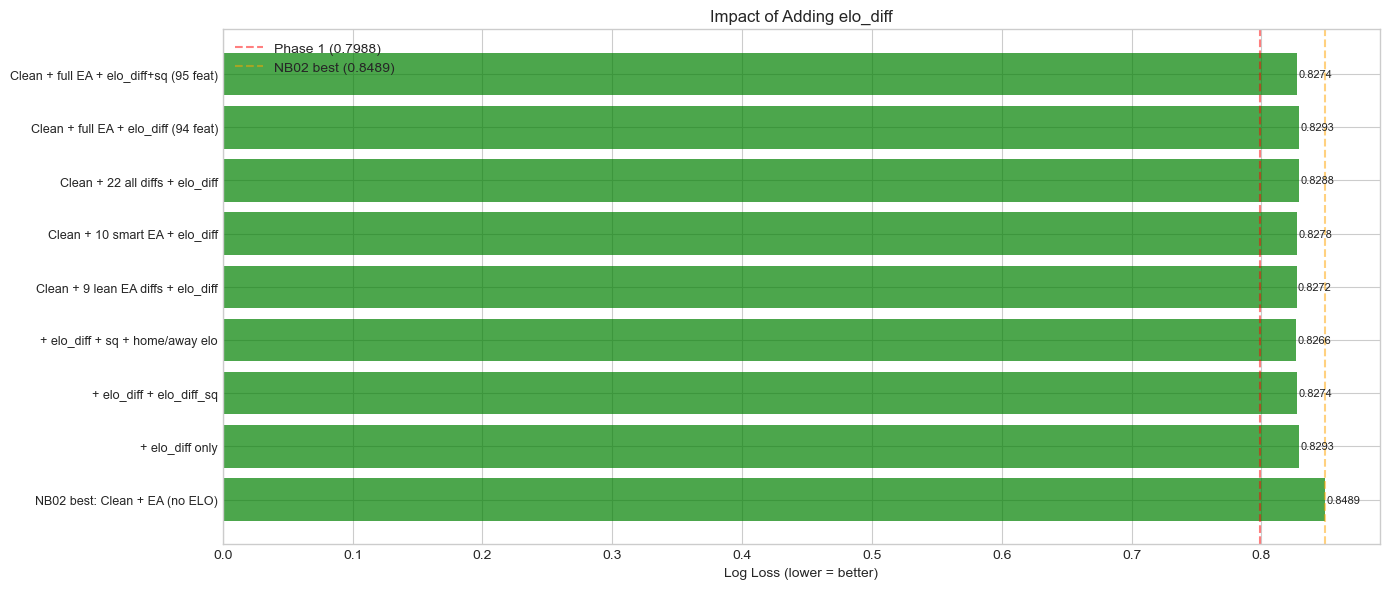

In [6]:
# Visualize: ELO impact
elo_results = [(n, nf, ll, acc, f1) for n, nf, ll, acc, f1 in results]

fig, ax = plt.subplots(figsize=(14, 6))
names = [r[0] for r in elo_results]
lls = [r[2] for r in elo_results]
colors = ['green' if 'elo' in n.lower() else 'steelblue' for n in names]

bars = ax.barh(range(len(names)), lls, color=colors, alpha=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Log Loss (lower = better)')
ax.set_title('Impact of Adding elo_diff')
ax.axvline(x=0.7988, color='red', linestyle='--', alpha=0.5, label='Phase 1 (0.7988)')
ax.axvline(x=0.8489, color='orange', linestyle='--', alpha=0.5, label='NB02 best (0.8489)')
ax.legend()

# Add values on bars
for i, (bar, ll) in enumerate(zip(bars, lls)):
    ax.text(ll + 0.001, i, f'{ll:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../../notebooks/images/phase2_03_elo_impact.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Hyperparameter Tuning

Take the best feature set from Step 1 and tune XGBoost properly.

In [7]:
# Pick the best feature set from Step 1
best_step1 = min(results, key=lambda x: x[2])
print(f'Best from Step 1: {best_step1[0]} — ll={best_step1[2]:.4f}')

# Use the feature set from the best result
# Let's build all candidate sets and pick
FEAT_SETS = {
    'NB02 best: Clean + EA (no ELO)': NB02_BEST,
    '+ elo_diff only': NB02_BEST + ELO_MINIMAL,
    '+ elo_diff + elo_diff_sq': NB02_BEST + ELO_SMALL,
    '+ elo_diff + sq + home/away elo': NB02_BEST + ELO_MEDIUM,
    'Clean + 9 lean EA diffs + elo_diff': BASE_CLEAN + EA_LEAN_9 + ELO_MINIMAL,
    'Clean + 10 smart EA + elo_diff': BASE_CLEAN + EA_SMART + ELO_MINIMAL,
    'Clean + 22 all diffs + elo_diff': BASE_CLEAN + EA_ALL_DIFFS + ELO_MINIMAL,
    'Clean + full EA + elo_diff (94 feat)': NB02_BEST + ELO_MINIMAL,
    'Clean + full EA + elo_diff+sq (95 feat)': NB02_BEST + ELO_SMALL,
}

BEST_FEATS = FEAT_SETS.get(best_step1[0], NB02_BEST + ELO_MINIMAL)
print(f'Using {len(BEST_FEATS)} features for tuning')

Best from Step 1: + elo_diff + sq + home/away elo — ll=0.8266
Using 97 features for tuning


In [8]:
# ── XGBoost hyperparameter sweep ──
print('\nXGBoost Hyperparameter Sweep')
print('=' * 85)

tune_results = []

# Learning rate sweep
print('\n[1] Learning rate sweep (n=200, depth=5):')
for lr in [0.01, 0.03, 0.05, 0.08, 0.1, 0.15]:
    params = dict(n_estimators=200, max_depth=5, learning_rate=lr,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0)
    m = CalibratedClassifierCV(
        xgb.XGBClassifier(**params, eval_metric='mlogloss', random_state=42, verbosity=0),
        method='isotonic', cv=5)
    m.fit(train_aug[BEST_FEATS].values, y_train)
    p = m.predict_proba(test_aug[BEST_FEATS].values)
    ll = log_loss(y_test, p)
    acc = accuracy_score(y_test, np.argmax(p, axis=1))
    tune_results.append(('XGB', f'lr={lr}', params, ll, acc))
    print(f'  lr={lr:5.3f}  ll={ll:.4f}  acc={acc:.4f}')


XGBoost Hyperparameter Sweep

[1] Learning rate sweep (n=200, depth=5):
  lr=0.010  ll=0.8309  acc=0.6218
  lr=0.030  ll=0.8265  acc=0.6245
  lr=0.050  ll=0.8266  acc=0.6278
  lr=0.080  ll=0.8302  acc=0.6266
  lr=0.100  ll=0.8304  acc=0.6278
  lr=0.150  ll=0.8338  acc=0.6215


In [9]:
# Find best LR
best_lr = min([t for t in tune_results if 'lr=' in t[1]], key=lambda x: x[3])
best_lr_val = best_lr[2]['learning_rate']
print(f'Best learning rate: {best_lr_val} (ll={best_lr[3]:.4f})')

# Tree count sweep with best LR
print(f'\n[2] N_estimators sweep (lr={best_lr_val}, depth=5):')
for n_est in [100, 200, 300, 500, 700, 1000]:
    params = dict(n_estimators=n_est, max_depth=5, learning_rate=best_lr_val,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0)
    m = CalibratedClassifierCV(
        xgb.XGBClassifier(**params, eval_metric='mlogloss', random_state=42, verbosity=0),
        method='isotonic', cv=5)
    m.fit(train_aug[BEST_FEATS].values, y_train)
    p = m.predict_proba(test_aug[BEST_FEATS].values)
    ll = log_loss(y_test, p)
    acc = accuracy_score(y_test, np.argmax(p, axis=1))
    tune_results.append(('XGB', f'n={n_est}', params, ll, acc))
    print(f'  n={n_est:>4d}  ll={ll:.4f}  acc={acc:.4f}')

Best learning rate: 0.03 (ll=0.8265)

[2] N_estimators sweep (lr=0.03, depth=5):
  n= 100  ll=0.8295  acc=0.6221
  n= 200  ll=0.8265  acc=0.6245
  n= 300  ll=0.8271  acc=0.6263
  n= 500  ll=0.8285  acc=0.6272
  n= 700  ll=0.8301  acc=0.6299
  n=1000  ll=0.8316  acc=0.6293


In [10]:
# Find best n_est
best_n = min([t for t in tune_results if 'n=' in t[1]], key=lambda x: x[3])
best_n_val = best_n[2]['n_estimators']
print(f'Best n_estimators: {best_n_val} (ll={best_n[3]:.4f})')

# Depth sweep
print(f'\n[3] Max depth sweep (lr={best_lr_val}, n={best_n_val}):')
for depth in [3, 4, 5, 6, 7, 8]:
    params = dict(n_estimators=best_n_val, max_depth=depth, learning_rate=best_lr_val,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0)
    m = CalibratedClassifierCV(
        xgb.XGBClassifier(**params, eval_metric='mlogloss', random_state=42, verbosity=0),
        method='isotonic', cv=5)
    m.fit(train_aug[BEST_FEATS].values, y_train)
    p = m.predict_proba(test_aug[BEST_FEATS].values)
    ll = log_loss(y_test, p)
    acc = accuracy_score(y_test, np.argmax(p, axis=1))
    tune_results.append(('XGB', f'd={depth}', params, ll, acc))
    print(f'  depth={depth}  ll={ll:.4f}  acc={acc:.4f}')

Best n_estimators: 200 (ll=0.8265)

[3] Max depth sweep (lr=0.03, n=200):
  depth=3  ll=0.8306  acc=0.6239
  depth=4  ll=0.8285  acc=0.6257
  depth=5  ll=0.8265  acc=0.6245
  depth=6  ll=0.8274  acc=0.6242
  depth=7  ll=0.8271  acc=0.6251
  depth=8  ll=0.8279  acc=0.6260


In [11]:
# Find best depth
best_d = min([t for t in tune_results if 'd=' in t[1]], key=lambda x: x[3])
best_d_val = best_d[2]['max_depth']
print(f'Best depth: {best_d_val} (ll={best_d[3]:.4f})')

# Regularization sweep
print(f'\n[4] Regularization sweep (lr={best_lr_val}, n={best_n_val}, d={best_d_val}):')
for alpha, lam in [(0.0, 0.5), (0.05, 0.5), (0.1, 1.0), (0.2, 1.0), (0.5, 1.5), (0.1, 2.0), (0.5, 2.0)]:
    params = dict(n_estimators=best_n_val, max_depth=best_d_val, learning_rate=best_lr_val,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=alpha, reg_lambda=lam)
    m = CalibratedClassifierCV(
        xgb.XGBClassifier(**params, eval_metric='mlogloss', random_state=42, verbosity=0),
        method='isotonic', cv=5)
    m.fit(train_aug[BEST_FEATS].values, y_train)
    p = m.predict_proba(test_aug[BEST_FEATS].values)
    ll = log_loss(y_test, p)
    acc = accuracy_score(y_test, np.argmax(p, axis=1))
    tune_results.append(('XGB', f'a={alpha},l={lam}', params, ll, acc))
    print(f'  alpha={alpha}, lambda={lam}  ll={ll:.4f}  acc={acc:.4f}')

# Subsample/colsample sweep
print(f'\n[5] Subsample/colsample sweep:')
best_reg = min([t for t in tune_results if 'a=' in t[1]], key=lambda x: x[3])
best_alpha = best_reg[2]['reg_alpha']
best_lam = best_reg[2]['reg_lambda']

for sub, col in [(0.7, 0.7), (0.7, 0.8), (0.8, 0.7), (0.8, 0.8), (0.85, 0.85), (0.9, 0.9), (1.0, 1.0)]:
    params = dict(n_estimators=best_n_val, max_depth=best_d_val, learning_rate=best_lr_val,
                  subsample=sub, colsample_bytree=col, reg_alpha=best_alpha, reg_lambda=best_lam)
    m = CalibratedClassifierCV(
        xgb.XGBClassifier(**params, eval_metric='mlogloss', random_state=42, verbosity=0),
        method='isotonic', cv=5)
    m.fit(train_aug[BEST_FEATS].values, y_train)
    p = m.predict_proba(test_aug[BEST_FEATS].values)
    ll = log_loss(y_test, p)
    acc = accuracy_score(y_test, np.argmax(p, axis=1))
    tune_results.append(('XGB', f'sub={sub},col={col}', params, ll, acc))
    print(f'  sub={sub}, col={col}  ll={ll:.4f}  acc={acc:.4f}')

Best depth: 5 (ll=0.8265)

[4] Regularization sweep (lr=0.03, n=200, d=5):
  alpha=0.0, lambda=0.5  ll=0.8284  acc=0.6236
  alpha=0.05, lambda=0.5  ll=0.8278  acc=0.6239
  alpha=0.1, lambda=1.0  ll=0.8265  acc=0.6245
  alpha=0.2, lambda=1.0  ll=0.8263  acc=0.6245
  alpha=0.5, lambda=1.5  ll=0.8263  acc=0.6248
  alpha=0.1, lambda=2.0  ll=0.8265  acc=0.6242
  alpha=0.5, lambda=2.0  ll=0.8268  acc=0.6248

[5] Subsample/colsample sweep:
  sub=0.7, col=0.7  ll=0.8271  acc=0.6248
  sub=0.7, col=0.8  ll=0.8270  acc=0.6263
  sub=0.8, col=0.7  ll=0.8273  acc=0.6266
  sub=0.8, col=0.8  ll=0.8263  acc=0.6248
  sub=0.85, col=0.85  ll=0.8268  acc=0.6257
  sub=0.9, col=0.9  ll=0.8271  acc=0.6257
  sub=1.0, col=1.0  ll=0.8283  acc=0.6263


In [12]:
# Best XGB params
best_xgb = min(tune_results, key=lambda x: x[3])
BEST_XGB_PARAMS = best_xgb[2]
print(f'\nBest XGB: {best_xgb[1]} — ll={best_xgb[3]:.4f}, acc={best_xgb[4]:.4f}')
print(f'Params: {BEST_XGB_PARAMS}')


Best XGB: a=0.5,l=1.5 — ll=0.8263, acc=0.6248
Params: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.5, 'reg_lambda': 1.5}


## 3. Architecture Comparison

Try different model types with best features.

In [13]:
print('ARCHITECTURE COMPARISON (best feature set)')
print('=' * 85)

arch_results = []

# 1. Best tuned XGB
m_xgb, p_xgb = test_model('XGB (tuned)', BEST_FEATS, BEST_XGB_PARAMS, xgb.XGBClassifier)
arch_results.append(('XGB', p_xgb))

# 2. HistGradientBoosting
hgb_params = dict(max_iter=best_n_val, max_depth=best_d_val, learning_rate=best_lr_val)
m_hgb, p_hgb = test_model('HistGBT', BEST_FEATS, hgb_params, HistGradientBoostingClassifier)
arch_results.append(('HGB', p_hgb))

# 3. Random Forest
rf_params = dict(n_estimators=500, max_depth=12, min_samples_leaf=5)
# RF can't handle NaN — need to fillna
train_rf = train_aug[BEST_FEATS].fillna(0).values
test_rf = test_aug[BEST_FEATS].fillna(0).values
rf = CalibratedClassifierCV(
    RandomForestClassifier(**rf_params, random_state=42, n_jobs=-1),
    method='isotonic', cv=5)
rf.fit(train_rf, y_train)
p_rf = rf.predict_proba(test_rf)
ll_rf = log_loss(y_test, p_rf)
acc_rf = accuracy_score(y_test, np.argmax(p_rf, axis=1))
results.append(('RF (500 trees)', len(BEST_FEATS), ll_rf, acc_rf, 0))
arch_results.append(('RF', p_rf))
print(f'  {"RF (500 trees)":55s} | {len(BEST_FEATS):>3d} feat | ll={ll_rf:.4f} | acc={acc_rf:.4f}')

# 4. Logistic Regression
lr_params = dict(C=1.0, max_iter=2000, solver='lbfgs', multi_class='multinomial')
m_lr, p_lr = test_model('Logistic Regression', BEST_FEATS, lr_params, LogisticRegression)
arch_results.append(('LR', p_lr))

ARCHITECTURE COMPARISON (best feature set)
  XGB (tuned)                                             |  97 feat | ll=0.8263 | acc=0.6248
  HistGBT                                                 |  97 feat | ll=0.8338 | acc=0.6251
  RF (500 trees)                                          |  97 feat | ll=0.8299 | acc=0.6212
  Logistic Regression                                     |  97 feat | ll=0.8434 | acc=0.6257


In [14]:
# 5. Ensemble blends
print('\nENSEMBLE BLENDS')
print('=' * 85)

def eval_blend(name, proba):
    ll = log_loss(y_test, proba)
    acc = accuracy_score(y_test, np.argmax(proba, axis=1))
    results.append((name, 0, ll, acc, 0))
    print(f'  {name:55s} | ll={ll:.4f} | acc={acc:.4f}')
    return proba

# XGB + HGB
eval_blend('XGB×3 + HGB×1', (3*p_xgb + 1*p_hgb) / 4)
eval_blend('XGB×2 + HGB×1', (2*p_xgb + 1*p_hgb) / 3)
eval_blend('XGB×1 + HGB×1', (1*p_xgb + 1*p_hgb) / 2)

# XGB + RF
eval_blend('XGB×4 + RF×1', (4*p_xgb + 1*p_rf) / 5)
eval_blend('XGB×3 + RF×1', (3*p_xgb + 1*p_rf) / 4)

# XGB + HGB + RF
eval_blend('XGB×3 + HGB×1 + RF×1', (3*p_xgb + 1*p_hgb + 1*p_rf) / 5)
eval_blend('XGB×2 + HGB×2 + RF×1', (2*p_xgb + 2*p_hgb + 1*p_rf) / 5)

# Add LR?
eval_blend('XGB×3 + HGB×1 + LR×1', (3*p_xgb + 1*p_hgb + 1*p_lr) / 5)


ENSEMBLE BLENDS
  XGB×3 + HGB×1                                           | ll=0.8271 | acc=0.6257
  XGB×2 + HGB×1                                           | ll=0.8275 | acc=0.6248
  XGB×1 + HGB×1                                           | ll=0.8287 | acc=0.6254
  XGB×4 + RF×1                                            | ll=0.8258 | acc=0.6260
  XGB×3 + RF×1                                            | ll=0.8258 | acc=0.6263
  XGB×3 + HGB×1 + RF×1                                    | ll=0.8265 | acc=0.6248
  XGB×2 + HGB×2 + RF×1                                    | ll=0.8276 | acc=0.6242
  XGB×3 + HGB×1 + LR×1                                    | ll=0.8272 | acc=0.6269


array([[0.36858245, 0.31993107, 0.31148648],
       [0.49230027, 0.26563894, 0.24206079],
       [0.15934161, 0.18941905, 0.65123934],
       ...,
       [0.07534691, 0.18760495, 0.73704814],
       [0.04579482, 0.12163768, 0.8325675 ],
       [0.08337771, 0.16049634, 0.75612595]])

## 4. Final Results

In [15]:
print('\n' + '=' * 90)
print('ALL RESULTS — sorted by log loss')
print('=' * 90)
print(f'{"Model":55s} | {"Feat":>4s} | {"LL":>8s} | {"Acc":>7s}')
print('-' * 85)
for name, nf, ll, acc, f1 in sorted(results, key=lambda x: x[2]):
    marker = ' <<<' if ll <= min(r[2] for r in results) + 0.0001 else ''
    print(f'{name:55s} | {nf:>4d} | {ll:>8.4f} | {acc:>7.4f}{marker}')

best = min(results, key=lambda x: x[2])
print(f'\nBest: {best[0]} — ll={best[2]:.4f}')
print(f'  vs NB02 (no ELO):  0.8489 (delta: {best[2]-0.8489:+.4f})')
print(f'  vs Phase 1:        0.7988 (gap:   {best[2]-0.7988:+.4f})')
print(f'  Gap closed:        {(0.8489-best[2])/(0.8489-0.7988)*100:.1f}% of the 0.05 gap')


ALL RESULTS — sorted by log loss
Model                                                   | Feat |       LL |     Acc
-------------------------------------------------------------------------------------
XGB×3 + RF×1                                            |    0 |   0.8258 |  0.6263 <<<
XGB×4 + RF×1                                            |    0 |   0.8258 |  0.6260 <<<
XGB (tuned)                                             |   97 |   0.8263 |  0.6248
XGB×3 + HGB×1 + RF×1                                    |    0 |   0.8265 |  0.6248
+ elo_diff + sq + home/away elo                         |   97 |   0.8266 |  0.6278
XGB×3 + HGB×1                                           |    0 |   0.8271 |  0.6257
Clean + 9 lean EA diffs + elo_diff                      |   58 |   0.8272 |  0.6251
XGB×3 + HGB×1 + LR×1                                    |    0 |   0.8272 |  0.6269
+ elo_diff + elo_diff_sq                                |   95 |   0.8274 |  0.6260
Clean + full EA + elo_diff+sq (9

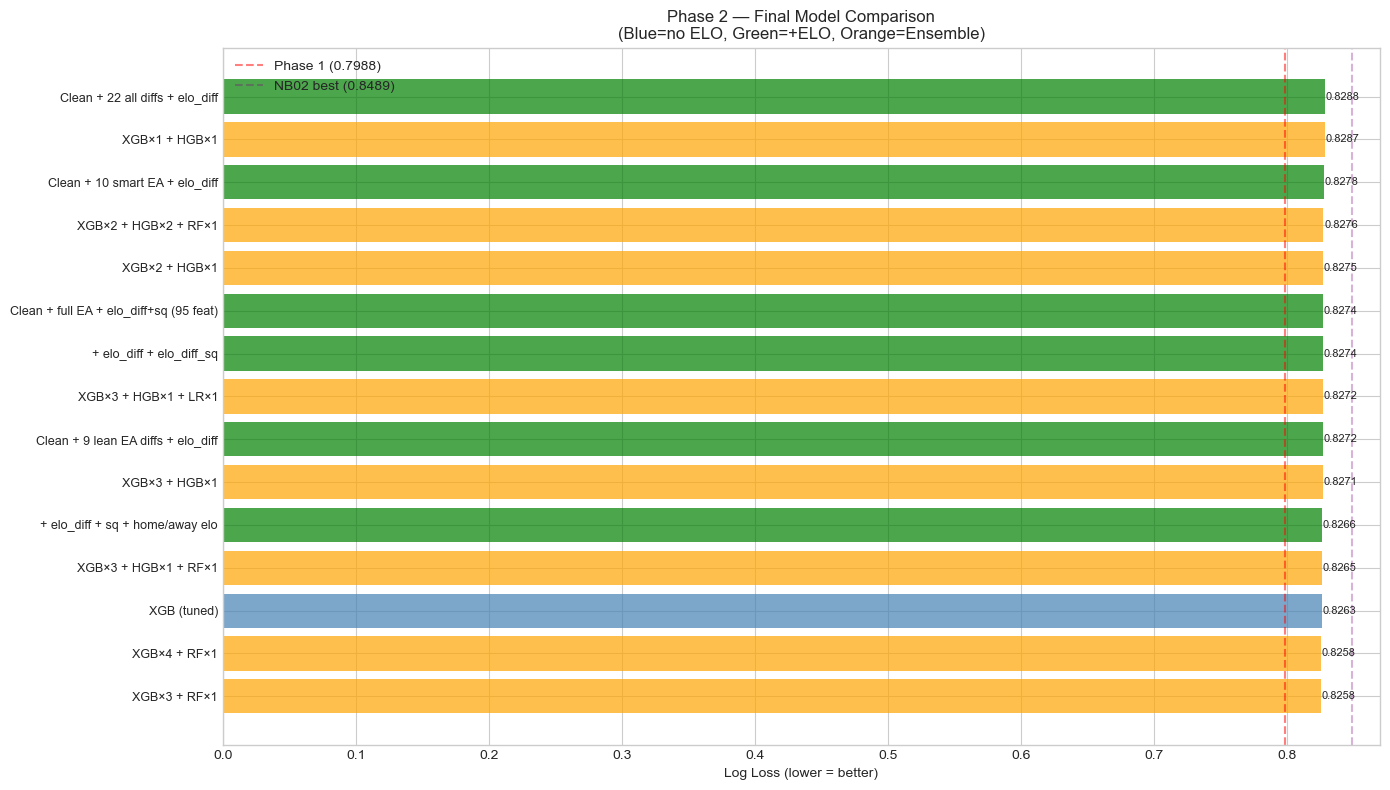

In [16]:
# Visualize final results
top_results = sorted(results, key=lambda x: x[2])[:15]

fig, ax = plt.subplots(figsize=(14, 8))
names = [r[0] for r in top_results]
lls = [r[2] for r in top_results]

colors = []
for n in names:
    if 'elo' not in n.lower() and 'ELO' not in n and '+' not in n.split('feat')[0]:
        colors.append('steelblue')
    elif 'blend' in n.lower() or '×' in n:
        colors.append('orange')
    else:
        colors.append('green')

bars = ax.barh(range(len(names)), lls, color=colors, alpha=0.7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.set_xlabel('Log Loss (lower = better)')
ax.set_title('Phase 2 — Final Model Comparison\n(Blue=no ELO, Green=+ELO, Orange=Ensemble)')
ax.axvline(x=0.7988, color='red', linestyle='--', alpha=0.5, label='Phase 1 (0.7988)')
ax.axvline(x=0.8489, color='purple', linestyle='--', alpha=0.3, label='NB02 best (0.8489)')
ax.legend()

for i, (bar, ll) in enumerate(zip(bars, lls)):
    ax.text(ll + 0.0005, i, f'{ll:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../../notebooks/images/phase2_03_final_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# Feature importance of the best model
best_xgb_raw = xgb.XGBClassifier(**BEST_XGB_PARAMS, eval_metric='mlogloss', random_state=42, verbosity=0)
best_xgb_raw.fit(train_aug[BEST_FEATS].values, y_train)
imp = best_xgb_raw.feature_importances_

feat_imp = sorted(zip(BEST_FEATS, imp), key=lambda x: -x[1])

print('Top 30 Feature Importance (best tuned XGB):')
print('=' * 65)
for i, (f, v) in enumerate(feat_imp[:30]):
    if f in ['elo_diff', 'elo_diff_sq', 'home_elo_before', 'away_elo_before']:
        tag = ' ★ ELO'
    elif f not in BASE_CLEAN:
        tag = ' ★ EA'
    else:
        tag = ''
    bar = '█' * int(v * 250)
    print(f'  {i+1:2d}. {f:35s}  {v:.4f}  {bar}{tag}')

# Category breakdown
elo_imp = sum(v for f, v in feat_imp if f in ELO_MINIMAL + ['elo_diff_sq', 'home_elo_before', 'away_elo_before'])
ea_imp = sum(v for f, v in feat_imp if f not in BASE_CLEAN and f not in ELO_MINIMAL + ['elo_diff_sq', 'home_elo_before', 'away_elo_before'])
base_imp = sum(v for f, v in feat_imp if f in BASE_CLEAN)
total = elo_imp + ea_imp + base_imp
print(f'\nImportance split: ELO={elo_imp/total*100:.1f}% | EA={ea_imp/total*100:.1f}% | Form/H2H/Context={base_imp/total*100:.1f}%')

Top 30 Feature Importance (best tuned XGB):
   1. elo_diff                             0.1440  ███████████████████████████████████ ★ ELO
   2. elo_diff_sq                          0.1407  ███████████████████████████████████ ★ ELO
   3. net_goal_diff                        0.0186  ████
   4. h2h_home_win_rate                    0.0182  ████
   5. h2h_recent_win_rate                  0.0175  ████
   6. away_conf_CAF                        0.0124  ███
   7. home_conf_CAF                        0.0124  ███
   8. home_avg_conceded_5                  0.0108  ██
   9. away_avg_conceded_10                 0.0108  ██
  10. home_conf_UNKNOWN                    0.0104  ██
  11. away_matches_played_10               0.0101  ██
  12. top3_ratio                           0.0099  ██ ★ EA
  13. h2h_home_avg_conceded                0.0098  ██
  14. away_elo_before                      0.0097  ██ ★ ELO
  15. neutral.1                            0.0096  ██
  16. away_goal_diff_form                  0.0095

## 5. Summary

**What we learned:**
1. How much does `elo_diff` close the gap?
2. Best hyperparameters?
3. Best architecture?
4. How does the importance split between ELO / EA / Form?

**Next:** If results are good — update production model and re-run WC simulation.